# Potential Outcomes SMD

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [2]:
import seaborn as sns
df = sns.load_dataset('titanic')
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
df['sex'].value_counts()
df["sex"] = df["sex"].map({"male": 1, "female": 0})
df["class"] = df["class"].map({"Third": 3, "Second": 2, "First": 1})
df['embarked'] = LabelEncoder().fit_transform(df['embarked']) 

In [4]:
df['age'].fillna(df['sex'].median(), inplace=True)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


class StandardizedMeanDifferenceAnalyzer:
    """
    Analyzes standardized mean differences between two groups in a dataset.
    """
    
    def __init__(self, df, group_col, features):
        self.df = df
        self.group_col = group_col
        self.features = features
        self.results = None
        
    def calculate(self):
        """
        Calculate standardized mean differences (Cohen's d) for all features.
        
        Returns:
        --------
        pd.DataFrame
            DataFrame with mean values for each group, raw delta, and standardized delta
        """

        group_means = self.df.groupby(self.group_col)[self.features].mean().T

        groups = sorted(self.df[self.group_col].unique())
        if len(groups) != 2:
            raise ValueError(f"Group column must have exactly 2 unique values, found {len(groups)}")
        
        group0, group1 = groups
        

        delta = group_means[group1] - group_means[group0]
        

        std0 = self.df[self.df[self.group_col] == group0][self.features].std()
        std1 = self.df[self.df[self.group_col] == group1][self.features].std()
        pooled_std = np.sqrt((std0**2 + std1**2) / 2)

        delta_std = abs(delta / pooled_std)

        self.results = pd.DataFrame({
            f'mean_{self.group_col}={group0}': group_means[group0],
            f'mean_{self.group_col}={group1}': group_means[group1],
            'delta': delta,
            'delta_std': delta_std
        })

        self.results = self.results.reindex(
            self.results['delta_std'].abs().sort_values(ascending=False).index
        )
        
        return self.results
    
    def plot(self, figsize=(7, 4), color='skyblue', title=None):

        if self.results is None:
            raise ValueError("Must call calculate() before plotting")
        
        plot_series = self.results['delta_std'].iloc[::-1] # .iloc[::-1] reverses the order
        
        plt.figure(figsize=figsize)
      
        plot_series.plot(kind='barh', color=color, edgecolor='black') 
        
        plt.axvline(0, color='black', linewidth=1)
        
     
        groups = self.df[self.group_col].unique()
        group0, group1 = sorted(groups)

        if title is None:
            title = f'Standardized Mean Difference ({self.group_col}={group1} vs {group0})'
        plt.title(title)
        
        plt.xlabel('Standardized Difference (SD units)')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
    
    def print_results(self, precision=3):

        if self.results is None:
            raise ValueError("Must call calculate() before printing results")
        
        print(self.results.round(precision))
    
    def run(self, plot=True, print_results=True, **plot_kwargs):
      
        self.calculate()
        
        if plot:
            self.plot(**plot_kwargs)
        
        if print_results:
            self.print_results()
        
        return self.results


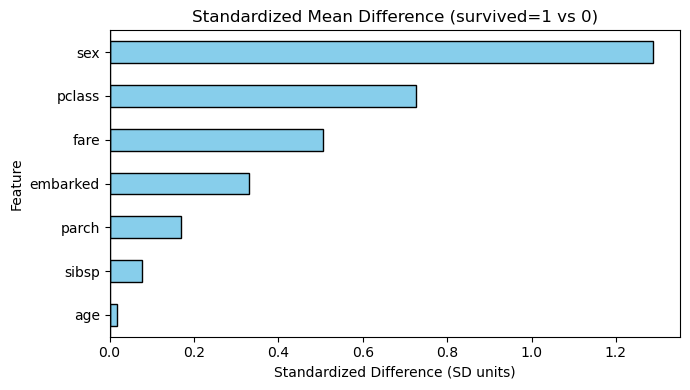

          mean_survived=0  mean_survived=1   delta  delta_std
sex                 0.852            0.319  -0.534      1.287
pclass              2.532            1.950  -0.582      0.725
fare               22.118           48.395  26.278      0.505
embarked            1.641            1.374  -0.267      0.332
parch               0.330            0.465   0.135      0.169
sibsp               0.554            0.474  -0.080      0.077
age                23.881           24.186   0.305      0.018


In [6]:
analyzer = StandardizedMeanDifferenceAnalyzer(df=df, group_col='survived', 
                                              features=['age', 'pclass', 'embarked', 'fare', 'sex', 'sibsp', 'parch']
)
results = analyzer.run()



In [7]:
"""
binned_smd.py
=============
Standardized Mean Difference analysis with a potential-outcomes framing.

The binary target defines two "worlds" (e.g. survived=0 / survived=1).
Every feature — raw, entropy-binned, or a pairwise interaction — becomes a
binary indicator whose SMD measures how unequally it is distributed across
those two worlds.

Classes
-------
EntropySplitter                      supervised binary/recursive splitter
StandardizedMeanDifferenceAnalyzer   original two-group SMD (unchanged)
PotentialOutcomesSMD                 main analyzer: base + interactions + heatmap
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from pathlib import Path


def _entropy(y: pd.Series) -> float:
    p = y.mean()
    if p in (0.0, 1.0):
        return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)


def _information_gain(x: pd.Series, y: pd.Series, threshold: float) -> float:
    left_mask = x <= threshold
    n = len(y)
    n_left, n_right = left_mask.sum(), (~left_mask).sum()
    if n_left == 0 or n_right == 0:
        return 0.0
    return (
        _entropy(y)
        - (n_left / n) * _entropy(y[left_mask])
        - (n_right / n) * _entropy(y[~left_mask])
    )


def _best_split(x: pd.Series, y: pd.Series) -> tuple[float, float]:
    candidates = x.sort_values().unique()
    midpoints = (candidates[:-1] + candidates[1:]) / 2
    best_gain, best_thresh = -np.inf, np.nan
    for thresh in midpoints:
        gain = _information_gain(x, y, thresh)
        if gain > best_gain:
            best_gain, best_thresh = gain, thresh
    return best_thresh, best_gain


class EntropySplitter:
    """
    Recursively splits a continuous variable to maximise information gain
    w.r.t. a binary target, producing up to `max_bins` bins.
    """

    def __init__(self, max_bins: int = 2, min_samples_leaf: int = 20):
        if max_bins < 2:
            raise ValueError("max_bins must be at least 2")
        self.max_bins = max_bins
        self.min_samples_leaf = min_samples_leaf
        self.thresholds_: list[float] = []

    def fit(self, x: pd.Series, y: pd.Series) -> "EntropySplitter":
        self.thresholds_ = []
        regions = [(x.index, "root")]

        for _ in range(self.max_bins - 1):
            best_gain_global = -np.inf
            best_thresh_global = None

            for idx, _ in regions:
                x_r, y_r = x.loc[idx], y.loc[idx]
                if len(x_r) < 2 * self.min_samples_leaf:
                    continue
                thresh, gain = _best_split(x_r, y_r)
                if gain > best_gain_global:
                    left_n = (x_r <= thresh).sum()
                    right_n = (x_r > thresh).sum()
                    if left_n >= self.min_samples_leaf and right_n >= self.min_samples_leaf:
                        best_gain_global = gain
                        best_thresh_global = thresh

            if best_thresh_global is None or best_gain_global <= 0:
                break

            self.thresholds_.append(best_thresh_global)
            thresholds_sorted = sorted(self.thresholds_)
            regions = []
            edges = [-np.inf] + thresholds_sorted + [np.inf]
            for i in range(len(edges) - 1):
                mask = (x > edges[i]) & (x <= edges[i + 1])
                regions.append((x[mask].index, f"bin_{i}"))

        return self

    def transform(self, x: pd.Series) -> pd.Series:
        if not self.thresholds_:
            raise ValueError("Call fit() before transform()")
        thresholds_sorted = sorted(self.thresholds_)
        edges = [-np.inf] + thresholds_sorted + [np.inf]
        name = x.name or "x"

        def _label(i):
            lo, hi = edges[i], edges[i + 1]
            if lo == -np.inf:
                return f"{name} ≤ {hi:.4g}"
            if hi == np.inf:
                return f"{name} > {lo:.4g}"
            return f"{lo:.4g} < {name} ≤ {hi:.4g}"

        labels = [_label(i) for i in range(len(edges) - 1)]
        return pd.cut(x, bins=edges, labels=labels)

    def fit_transform(self, x: pd.Series, y: pd.Series) -> pd.Series:
        return self.fit(x, y).transform(x)

    @property
    def n_bins(self) -> int:
        return len(self.thresholds_) + 1



# StandardizedMeanDifferenceAnalyzer  (original)


class StandardizedMeanDifferenceAnalyzer:
    """Analyzes standardized mean differences between two groups in a dataset."""

    def __init__(self, df, group_col, features):
        self.df = df
        self.group_col = group_col
        self.features = features
        self.results = None

    def calculate(self):
        group_means = self.df.groupby(self.group_col)[self.features].mean().T
        groups = sorted(self.df[self.group_col].unique())
        if len(groups) != 2:
            raise ValueError(
                f"Group column must have exactly 2 unique values, found {len(groups)}"
            )

        group0, group1 = groups
        delta = group_means[group1] - group_means[group0]
        std0 = self.df[self.df[self.group_col] == group0][self.features].std()
        std1 = self.df[self.df[self.group_col] == group1][self.features].std()
        pooled_std = np.sqrt((std0 ** 2 + std1 ** 2) / 2)
        delta_std = abs(delta / pooled_std)

        self.results = pd.DataFrame({
            f'mean_{self.group_col}={group0}': group_means[group0],
            f'mean_{self.group_col}={group1}': group_means[group1],
            'delta': delta,
            'delta_std': delta_std,
        })
        self.results = self.results.reindex(
            self.results['delta_std'].abs().sort_values(ascending=False).index
        )
        return self.results

    def plot(self, figsize=(7, 4), color='skyblue', title=None, ax=None):
        if self.results is None:
            raise ValueError("Must call calculate() before plotting")

        plot_series = self.results['delta_std'].iloc[::-1]
        standalone = ax is None
        if standalone:
            _, ax = plt.subplots(figsize=figsize)

        plot_series.plot(kind='barh', color=color, edgecolor='black', ax=ax)
        ax.axvline(0, color='black', linewidth=1)
        groups = sorted(self.df[self.group_col].unique())
        group0, group1 = groups
        if title is None:
            title = f'SMD  ({self.group_col}={group1} vs {group0})'
        ax.set_title(title)
        ax.set_xlabel('Standardized Difference (SD units)')
        ax.set_ylabel('Feature')

        if standalone:
            plt.tight_layout()
            plt.show()

    def print_results(self, precision=3):
        if self.results is None:
            raise ValueError("Must call calculate() before printing results")
        print(self.results.round(precision))

    def run(self, plot=True, print_results=True, **plot_kwargs):
        self.calculate()
        if plot:
            self.plot(**plot_kwargs)
        if print_results:
            self.print_results()
        return self.results



# PotentialOutcomesSMD


class PotentialOutcomesSMD:
    """
    SMD analysis framed as a potential-outcomes problem.

    The binary target defines two worlds (e.g. survived=0 / survived=1).
    Every feature — raw continuous, entropy-binned indicator, or pairwise
    interaction — becomes a row whose mean_group=0 / mean_group=1 columns
    show the proportion of each world satisfying that condition.
    A large delta_std means the condition is unequally distributed across
    the two worlds, i.e. it is informative about which world a unit ended up in.

    Parameters
    ----------
    df : pd.DataFrame
    target_col : str
        Binary outcome column (e.g. 'survived').
    raw_features : list[str], optional
        Numeric columns included as-is (mean compared between groups).
    features_to_bin : list[str], optional
        Continuous columns entropy-split into binary indicators.
    categorical_features : list[str], optional
        Categorical/binary columns whose levels become indicators.
    max_bins : int
        Max bins per entropy-split variable (default 3 → up to two splits).
    min_samples_leaf : int
        Min samples per leaf for entropy splits.
    min_subgroup_size : int
        Interaction terms with fewer positive cases are dropped.
    output_dir : str or Path, optional
        Directory where all plots are saved as PNG files.
        If None (default), plots are displayed interactively instead.

    Example
    -------
    >>> analyzer = PotentialOutcomesSMD(
    ...     df=titanic,
    ...     target_col='survived',
    ...     raw_features=['fare', 'age'],
    ...     features_to_bin=['fare', 'age'],
    ...     categorical_features=['sex', 'pclass'],
    ...     max_bins=2,
    ...     output_dir='./plots',
    ... )
    >>> results = analyzer.run()
    """

    def __init__(
        self,
        df: pd.DataFrame,
        target_col: str,
        raw_features: list[str] | None = None,
        features_to_bin: list[str] | None = None,
        categorical_features: list[str] | None = None,
        max_bins: int = 3,
        min_samples_leaf: int = 20,
        min_subgroup_size: int = 30,
        output_dir: str | Path | None = None,
    ):
        self.df = df.copy()
        self.target_col = target_col
        self.raw_features = list(raw_features or [])
        self.features_to_bin = list(features_to_bin or [])
        self.categorical_features = list(categorical_features or [])
        self.max_bins = max_bins
        self.min_samples_leaf = min_samples_leaf
        self.min_subgroup_size = min_subgroup_size

        
        if output_dir is not None:
            self.output_dir = Path(output_dir)
            self.output_dir.mkdir(parents=True, exist_ok=True)
        else:
            self.output_dir = None

        self.splitters_: dict[str, EntropySplitter] = {}
        self._working_df: pd.DataFrame | None = None
        self._indicators: dict[str, list[str]] = {}

        self.base_results_: pd.DataFrame | None = None
        self.interaction_results_: pd.DataFrame | None = None
        self.full_results_: pd.DataFrame | None = None

    

    def _save_or_show(self, fig: plt.Figure, filename: str) -> None:
        """Save fig to output_dir/filename.png, or show interactively if no dir set."""
        if self.output_dir is not None:
            path = self.output_dir / filename
            fig.savefig(path, bbox_inches='tight', dpi=150)
            plt.close(fig)
            print(f"  saved → {path}")
        else:
            plt.tight_layout()
            plt.show()

    # ── Step 1: build indicators ──────────────────────────────────────────────

    def _build_indicators(self):
        self._working_df = self.df.copy()
        self._indicators = {}

        for col in self.features_to_bin:
            clean = self._working_df[[col, self.target_col]].dropna()
            x, y = clean[col], clean[self.target_col]

            splitter = EntropySplitter(
                max_bins=self.max_bins,
                min_samples_leaf=self.min_samples_leaf,
            )
            splitter.fit(x, y)
            self.splitters_[col] = splitter

            if not splitter.thresholds_:
                print(f"[EntropySplitter] '{col}' → no informative split, skipped")
                continue

            thresholds_sorted = sorted(splitter.thresholds_)
            edges = [-np.inf] + thresholds_sorted + [np.inf]
            print(f"[EntropySplitter] '{col}' → {splitter.n_bins} bins  "
                  f"@ {[round(t, 4) for t in thresholds_sorted]}")

            self._indicators[col] = []
            for i in range(len(edges) - 1):
                lo, hi = edges[i], edges[i + 1]
                label = (
                    f"{col} ≤ {hi:.4g}" if lo == -np.inf else
                    f"{col} > {lo:.4g}" if hi == np.inf else
                    f"{lo:.4g} < {col} ≤ {hi:.4g}"
                )
                ind = ((self._working_df[col] > lo) &
                       (self._working_df[col] <= hi)).astype(float)
                ind[self._working_df[col].isna()] = np.nan
                self._working_df[label] = ind
                self._indicators[col].append(label)

        for col in self.categorical_features:
            levels = sorted(self._working_df[col].dropna().unique())
            self._indicators[col] = []
            for lvl in levels:
                label = f"{col}={lvl}"
                ind = (self._working_df[col] == lvl).astype(float)
                ind[self._working_df[col].isna()] = np.nan
                self._working_df[label] = ind
                self._indicators[col].append(label)
            print(f"[Categorical]    '{col}' → {len(levels)} indicators  "
                  f"({', '.join(str(l) for l in levels)})")

    # ── Step 2: base SMD ──────────────────────────────────────────────────────

    def _compute_base_smd(self):
        all_indicator_cols = [col for v in self._indicators for col in self._indicators[v]]
        all_features = self.raw_features + all_indicator_cols

        analyzer = StandardizedMeanDifferenceAnalyzer(
            df=self._working_df,
            group_col=self.target_col,
            features=all_features,
        )
        self.base_results_ = analyzer.calculate()

    # ── Step 3: interaction discovery ─────────────────────────────────────────

    def _compute_interactions(self):
        source_vars = [v for v in self._indicators if self._indicators[v]]
        groups = sorted(self._working_df[self.target_col].dropna().unique())
        g0, g1 = groups
        m0, m1 = f'mean_{self.target_col}={g0}', f'mean_{self.target_col}={g1}'

        rows = []
        for var_a, var_b in combinations(source_vars, 2):
            for bin_a in self._indicators[var_a]:
                for bin_b in self._indicators[var_b]:
                    ind_a = self._working_df[bin_a]
                    ind_b = self._working_df[bin_b]
                    interaction = ind_a * ind_b

                    valid = (interaction.notna() &
                             self._working_df[self.target_col].notna())
                    n_positive = interaction[valid].sum()

                    if n_positive < self.min_subgroup_size:
                        continue

                    grp0 = valid & (self._working_df[self.target_col] == g0)
                    grp1 = valid & (self._working_df[self.target_col] == g1)

                    mean0 = interaction[grp0].mean()
                    mean1 = interaction[grp1].mean()
                    delta = mean1 - mean0

                    std0 = interaction[grp0].std()
                    std1 = interaction[grp1].std()
                    pooled_std = np.sqrt((std0 ** 2 + std1 ** 2) / 2)
                    delta_std = abs(delta / pooled_std) if pooled_std > 0 else np.nan

                    rows.append({
                        'feature':   f"{bin_a}  &  {bin_b}",
                        'var_a':     var_a,
                        'var_b':     var_b,
                        'bin_a':     bin_a,
                        'bin_b':     bin_b,
                        m0:          mean0,
                        m1:          mean1,
                        'delta':     delta,
                        'delta_std': delta_std,
                        'n':         int(n_positive),
                    })

        if rows:
            self.interaction_results_ = (
                pd.DataFrame(rows)
                .set_index('feature')
                .sort_values('delta_std', ascending=False)
            )
        else:
            self.interaction_results_ = pd.DataFrame()

    # ── Step 4: merge ─────────────────────────────────────────────────────────

    def _merge_results(self):
        groups = sorted(self._working_df[self.target_col].dropna().unique())
        g0, g1 = groups
        m0, m1 = f'mean_{self.target_col}={g0}', f'mean_{self.target_col}={g1}'

        base = self.base_results_[[m0, m1, 'delta', 'delta_std']].copy()
        base['layer'] = 'base'

        if not self.interaction_results_.empty:
            inter = self.interaction_results_[[m0, m1, 'delta', 'delta_std']].copy()
            inter['layer'] = 'interaction'
            self.full_results_ = pd.concat([base, inter])
        else:
            self.full_results_ = base

        self.full_results_ = self.full_results_.sort_values('delta_std', ascending=False)

    # ── Plots ──────────────────────────────────────────────────────────────────

    def plot_base(self, figsize=(10, 6), title=None):
        if self.base_results_ is None:
            raise ValueError("Call run() first")

        groups = sorted(self._working_df[self.target_col].dropna().unique())
        g0, g1 = groups
        plot_series = self.base_results_['delta_std'].iloc[::-1]

        raw_set = set(self.raw_features)
        bin_set = {col for v in self.features_to_bin for col in self._indicators.get(v, [])}
        cat_set = {col for v in self.categorical_features for col in self._indicators.get(v, [])}

        colors = []
        for feat in plot_series.index:
            if feat in raw_set:
                colors.append('steelblue')
            elif feat in cat_set:
                colors.append('mediumseagreen')
            else:
                colors.append('coral')

        fig, ax = plt.subplots(figsize=figsize)
        plot_series.plot(kind='barh', color=colors, edgecolor='black', ax=ax)
        ax.axvline(0, color='black', linewidth=1)

        legend_items = []
        if self.raw_features:
            legend_items.append(mpatches.Patch(color='steelblue', label='raw feature'))
        if self.features_to_bin:
            legend_items.append(mpatches.Patch(color='coral', label='entropy-binned indicator'))
        if self.categorical_features:
            legend_items.append(mpatches.Patch(color='mediumseagreen', label='categorical indicator'))
        if legend_items:
            ax.legend(handles=legend_items, loc='lower right', fontsize=9)

        if title is None:
            title = (f'Base SMD  —  {self.target_col}={g1} vs {self.target_col}={g0}\n'
                     f'indicator rows = proportion of each world satisfying that condition')
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Standardized Difference (SD units)')
        ax.set_ylabel('Feature / Condition')

        self._save_or_show(fig, 'smd_base.png')

    def plot_top_interactions(self, top_n: int = 15, figsize=(10, 6)):
        if self.interaction_results_ is None or self.interaction_results_.empty:
            print("No interaction results to plot.")
            return

        groups = sorted(self._working_df[self.target_col].dropna().unique())
        g0, g1 = groups
        plot_series = self.interaction_results_.head(top_n)['delta_std'].iloc[::-1]

        fig, ax = plt.subplots(figsize=figsize)
        plot_series.plot(kind='barh', color='mediumpurple', edgecolor='black', ax=ax)
        ax.axvline(0, color='black', linewidth=1)
        ax.set_title(
            f'Top {top_n} Interaction Terms  —  {self.target_col}={g1} vs {g0}\n'
            f'(proportion of each world satisfying both conditions jointly)',
            fontsize=11
        )
        ax.set_xlabel('Standardized Difference (SD units)')
        ax.set_ylabel('Interaction Condition')

        self._save_or_show(fig, 'smd_interactions.png')

    def plot_interaction_heatmap(self, figsize=None):
        if self.interaction_results_ is None or self.interaction_results_.empty:
            print("No interaction results to plot.")
            return

        pairs = list(self.interaction_results_.groupby(['var_a', 'var_b']))
        n_pairs = len(pairs)
        ncols = min(n_pairs, 3)
        nrows = int(np.ceil(n_pairs / ncols))
        if figsize is None:
            figsize = (6 * ncols, 4 * nrows)

        fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)

        for idx, ((var_a, var_b), group_df) in enumerate(pairs):
            ax = axes[idx // ncols][idx % ncols]

            bins_a = self._indicators.get(var_a, [])
            bins_b = self._indicators.get(var_b, [])

            matrix = pd.DataFrame(np.nan, index=bins_a, columns=bins_b)
            for feat, row in group_df.iterrows():
                ba, bb = row['bin_a'], row['bin_b']
                if ba in matrix.index and bb in matrix.columns:
                    matrix.loc[ba, bb] = row['delta_std']

            def _short(label, var):
                return (label
                        .replace(f"{var} ≤ ", "≤ ")
                        .replace(f"{var} > ", "> ")
                        .replace(f"{var}=", ""))

            row_labels = [_short(b, var_a) for b in bins_a]
            col_labels = [_short(b, var_b) for b in bins_b]

            mat_vals = matrix.values.astype(float)
            vmax = np.nanmax(mat_vals) if not np.all(np.isnan(mat_vals)) else 1.0

            im = ax.imshow(mat_vals, cmap='YlOrRd', aspect='auto', vmin=0, vmax=vmax)
            plt.colorbar(im, ax=ax, shrink=0.8, label='delta_std')

            ax.set_xticks(range(len(col_labels)))
            ax.set_yticks(range(len(row_labels)))
            ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=9)
            ax.set_yticklabels(row_labels, fontsize=9)
            ax.set_xlabel(var_b, fontsize=10)
            ax.set_ylabel(var_a, fontsize=10)
            ax.set_title(f'{var_a}  ×  {var_b}', fontsize=11)

            for i in range(len(bins_a)):
                for j in range(len(bins_b)):
                    val = matrix.iloc[i, j]
                    if not np.isnan(val):
                        text_color = 'white' if val > 0.6 * vmax else 'black'
                        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                                fontsize=9, color=text_color)

        for idx in range(n_pairs, nrows * ncols):
            axes[idx // ncols][idx % ncols].set_visible(False)

        fig.suptitle(
            'Interaction SMD Heatmaps\n'
            'cell = delta_std of joint condition  (darker = more discriminative)',
            fontsize=12, y=1.01
        )

        self._save_or_show(fig, 'smd_heatmap.png')

    # ── Print ──────────────────────────────────────────────────────────────────

    def print_results(self, layer: str = 'full', precision: int = 3,
                      top_n: int | None = None):
        """layer: 'base' | 'interaction' | 'full'"""
        mapping = {
            'base':        self.base_results_,
            'interaction': self.interaction_results_,
            'full':        self.full_results_,
        }
        df = mapping.get(layer)
        if df is None or (hasattr(df, 'empty') and df.empty):
            print(f"No results for layer='{layer}'")
            return
        groups = sorted(self._working_df[self.target_col].dropna().unique())
        g0, g1 = groups
        print(f"\n── SMD Results ({layer})  |  "
              f"{self.target_col}={g1} vs {self.target_col}={g0} ──")
        out = df.head(top_n) if top_n else df
        print(out.round(precision).to_string())

    # ── Main entry point ───────────────────────────────────────────────────────

    def run(
        self,
        plot_base: bool = True,
        plot_interactions: bool = True,
        print_results: bool = True,
        top_n_interactions: int = 15,
    ) -> pd.DataFrame:
        """
        Full pipeline:
          1. Build entropy-binned + categorical indicators
          2. Compute base SMD (raw features + indicators vs target)
          3. Compute all pairwise interaction SMDs
          4. Merge into a single ranked table

        Plots are saved to output_dir (if set) or shown interactively.
        Returns full_results_ DataFrame.
        """
        print("── Building indicators ──────────────────────────────────────")
        self._build_indicators()

        print("\n── Computing base SMD ───────────────────────────────────────")
        self._compute_base_smd()

        print("\n── Computing interaction SMD ────────────────────────────────")
        self._compute_interactions()
        n_inter = 0 if self.interaction_results_.empty else len(self.interaction_results_)
        print(f"   {n_inter} interaction terms computed "
              f"(min_subgroup_size={self.min_subgroup_size})")

        self._merge_results()

        if self.output_dir is not None:
            print(f"\n── Saving plots to {self.output_dir} ────────────────────")

        if plot_base:
            self.plot_base()

        if plot_interactions and n_inter > 0:
            self.plot_top_interactions(top_n=top_n_interactions)
            self.plot_interaction_heatmap()

        if print_results:
            self.print_results(layer='base')
            if n_inter > 0:
                self.print_results(layer='interaction', top_n=top_n_interactions)

        return self.full_results_

In [10]:
analyzer = PotentialOutcomesSMD(
    df=df,
    target_col='survived',
    raw_features=['sibsp'],
    features_to_bin=['fare', 'age'],
    categorical_features=['sex', 'pclass'],
    max_bins=3,
    min_subgroup_size=30,
    output_dir='./titanic_plots'
)
results = analyzer.run()

── Building indicators ──────────────────────────────────────
[EntropySplitter] 'fare' → 3 bins  @ [10.4812, 74.375]
[EntropySplitter] 'age' → no informative split, skipped
[Categorical]    'sex' → 2 indicators  (0, 1)
[Categorical]    'pclass' → 3 indicators  (1, 2, 3)

── Computing base SMD ───────────────────────────────────────

── Computing interaction SMD ────────────────────────────────
   17 interaction terms computed (min_subgroup_size=30)

── Saving plots to titanic_plots ────────────────────
  saved → titanic_plots/smd_base.png
  saved → titanic_plots/smd_interactions.png
  saved → titanic_plots/smd_heatmap.png

── SMD Results (base)  |  survived=1 vs survived=0 ──
                      mean_survived=0  mean_survived=1  delta  delta_std
sex=0                           0.148            0.681  0.534      1.287
sex=1                           0.852            0.319 -0.534      1.287
pclass=3                        0.678            0.348 -0.330      0.698
fare ≤ 10.48           

### Second dataset

In [9]:
df_diabetes = pd.read_csv('diabetes.csv')
df_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
analyzer = PotentialOutcomesSMD(
    df=df_diabetes,
    target_col='Outcome',
    raw_features=[],
    features_to_bin=['Pregnancies','Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age' ],
    categorical_features=[],
    max_bins=2,
    min_subgroup_size=30,
    output_dir='./diabetes_plots'
    
)
results = analyzer.run()

── Building indicators ──────────────────────────────────────
[EntropySplitter] 'Pregnancies' → 2 bins  @ [6.5]
[EntropySplitter] 'Glucose' → 2 bins  @ [127.5]
[EntropySplitter] 'BloodPressure' → 2 bins  @ [69.0]
[EntropySplitter] 'SkinThickness' → 2 bins  @ [31.5]
[EntropySplitter] 'Insulin' → 2 bins  @ [121.0]
[EntropySplitter] 'BMI' → 2 bins  @ [27.85]
[EntropySplitter] 'DiabetesPedigreeFunction' → 2 bins  @ [0.5275]
[EntropySplitter] 'Age' → 2 bins  @ [28.5]

── Computing base SMD ───────────────────────────────────────

── Computing interaction SMD ────────────────────────────────
   109 interaction terms computed (min_subgroup_size=30)

── Saving plots to diabetes_plots ────────────────────
  saved → diabetes_plots/smd_base.png
  saved → diabetes_plots/smd_interactions.png
  saved → diabetes_plots/smd_heatmap.png

── SMD Results (base)  |  Outcome=1 vs Outcome=0 ──
                                   mean_Outcome=0  mean_Outcome=1  delta  delta_std
Glucose ≤ 127.5                 

### Third dataset: Adult Census Income

In [11]:
from sklearn.datasets import fetch_openml

# Load Adult Census dataset (UCI Adult / Census Income)
adult_raw = fetch_openml(name='adult', version=2, as_frame=True, parser='auto')
df_adult = adult_raw.frame.copy()
print(df_adult.shape)
df_adult.head()

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [12]:
# Preprocessing
df_adult = df_adult.dropna().reset_index(drop=True)

# Binary target: 1 = ">50K", 0 = "<=50K"
df_adult['income'] = (df_adult['class'].str.strip().str.replace('.', '', regex=False) == '>50K').astype(int)
df_adult = df_adult.drop(columns=['class'])

# Drop fnlwgt (sampling weight — not a meaningful feature)
df_adult = df_adult.drop(columns=['fnlwgt'])

# Ensure numeric columns are float
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
for col in num_cols:
    df_adult[col] = pd.to_numeric(df_adult[col], errors='coerce')

print("Shape after cleaning:", df_adult.shape)
print("\nClass balance:\n", df_adult['income'].value_counts())
print("\nDtypes:\n", df_adult.dtypes)

Shape after cleaning: (45222, 14)

Class balance:
 0    34014
1    11208
Name: income, dtype: int64

Dtypes:
 age                  int64
workclass         category
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
income               int64
dtype: object


In [14]:
analyzer_adult = PotentialOutcomesSMD(
    df=df_adult,
    target_col='income',
    raw_features=[],
    features_to_bin=['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week'],
    categorical_features=['sex', 'workclass', 'marital-status', 'occupation', 'relationship', 'race'],
    max_bins=2,
    min_subgroup_size=200,
    output_dir='./adult_plots'
)
results_adult = analyzer_adult.run()

── Building indicators ──────────────────────────────────────
[EntropySplitter] 'age' → 2 bins  @ [27.5]
[EntropySplitter] 'education-num' → 2 bins  @ [12.5]
[EntropySplitter] 'capital-gain' → 2 bins  @ [7055.5]
[EntropySplitter] 'capital-loss' → 2 bins  @ [1820.5]
[EntropySplitter] 'hours-per-week' → 2 bins  @ [41.5]
[Categorical]    'sex' → 2 indicators  (Female, Male)
[Categorical]    'workclass' → 7 indicators  (Federal-gov, Local-gov, Private, Self-emp-inc, Self-emp-not-inc, State-gov, Without-pay)
[Categorical]    'marital-status' → 7 indicators  (Divorced, Married-AF-spouse, Married-civ-spouse, Married-spouse-absent, Never-married, Separated, Widowed)
[Categorical]    'occupation' → 14 indicators  (Adm-clerical, Armed-Forces, Craft-repair, Exec-managerial, Farming-fishing, Handlers-cleaners, Machine-op-inspct, Other-service, Priv-house-serv, Prof-specialty, Protective-serv, Sales, Tech-support, Transport-moving)
[Categorical]    'relationship' → 6 indicators  (Husband, Not-in-fa